In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('data/train.csv')

In [3]:
df.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [4]:
df.isna().sum()

id                         0
Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

In [5]:
df.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Heart Disease  

In [6]:
for each in df.columns:
    print(each, df[each].nunique())

id 630000
Age 42
Sex 2
Chest pain type 4
BP 66
Cholesterol 150
FBS over 120 2
EKG results 3
Max HR 93
Exercise angina 2
ST depression 66
Slope of ST 3
Number of vessels fluro 4
Thallium 3
Heart Disease 2


There are 15 Variables which can decide the output variable..

id ID of Patient
Age Age of the Patient (Continous Variable)
Sex Sex of the patient M/F (Categorical Variable)
Chest pain type (Categorical Variable)
BP 66 (Continous Variable)
Cholesterol 150 (Continous Variable)
FBS over 120  (Categorical Variable)
EKG results  (Categorical Variable)
Max HR  (Continous Variable)
Exercise angina (Categorical Variable)
ST depression 66 (Continous Variable)
Slope of ST (Categorical Variable)
Number of vessels fluro (Categorical Variable)
Thallium (Categorical Variable)
Heart Disease (Categorical Variable)

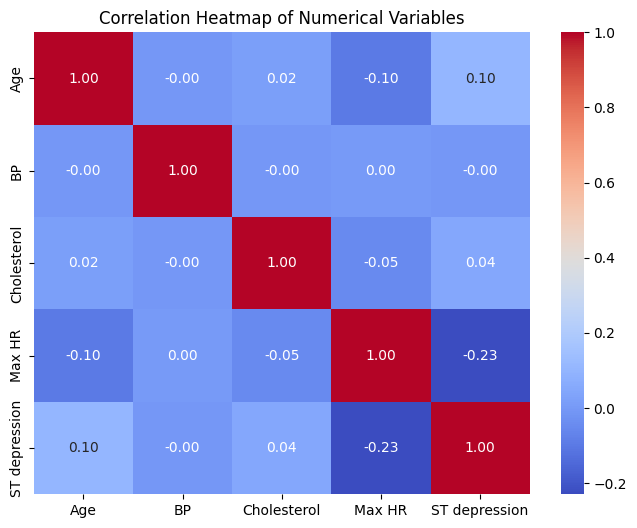

In [7]:
import seaborn as sns

# Correlation heatmap for numerical variables
numerical_cols = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']
corr = df[numerical_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

In [8]:
print(corr)

                    Age        BP  Cholesterol    Max HR  ST depression
Age            1.000000 -0.003960     0.019485 -0.097542       0.103064
BP            -0.003960  1.000000    -0.004597  0.004391      -0.004024
Cholesterol    0.019485 -0.004597     1.000000 -0.048575       0.044678
Max HR        -0.097542  0.004391    -0.048575  1.000000      -0.229462
ST depression  0.103064 -0.004024     0.044678 -0.229462       1.000000


In [3]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np

# Create a copy for preprocessing
df_processed = df.copy()

# Identify categorical and continuous variables
categorical_cols = ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 
                   'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium']
continuous_cols = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']

# Encode categorical variables using LabelEncoder
le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col])
    le_dict[col] = le

# Normalize continuous variables using StandardScaler
scaler = StandardScaler()
df_processed[continuous_cols] = scaler.fit_transform(df_processed[continuous_cols])

# Encode target variable
le_target = LabelEncoder()
df_processed['Heart Disease'] = le_target.fit_transform(df_processed['Heart Disease'])

print("Categorical variables encoded successfully!")
print("\nFirst few rows after encoding and normalization:")
print(df_processed.head())
print("\nData types after preprocessing:")
print(df_processed.dtypes)
print("\nStatistics of normalized continuous variables:")
print(df_processed[continuous_cols].describe())

Categorical variables encoded successfully!

First few rows after encoding and normalization:
   id       Age  Sex  Chest pain type        BP  Cholesterol  FBS over 120  \
0   0  0.467921    1                3  1.435822    -0.178490             0   
1   1 -0.258797    1                0 -0.367088     2.374837             0   
2   2  0.225682    0                1  1.970017    -1.692672             0   
3   3 -1.227755    0                2  0.233882    -0.475388             0   
4   4  0.467921    1                3  0.634529    -0.326939             0   

   EKG results    Max HR  Exercise angina  ST depression  Slope of ST  \
0            0  0.271190                1       3.040655            1   
1            2  0.951359                0      -0.754928            0   
2            2 -0.095054                0      -0.754928            0   
3            2 -0.147375                0       0.299400            1   
4            2 -1.455391                1       3.251520            1   

In [4]:
# Display encoding mappings
print("=" * 60)
print("CATEGORICAL VARIABLE ENCODING MAPPINGS")
print("=" * 60)

for col in categorical_cols:
    print(f"\n{col}:")
    mapping = dict(zip(le_dict[col].classes_, le_dict[col].transform(le_dict[col].classes_)))
    for original, encoded in mapping.items():
        print(f"  {original} -> {encoded}")

print(f"\nTarget Variable (Heart Disease):")
mapping = dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))
for original, encoded in mapping.items():
    print(f"  {original} -> {encoded}")

print("\n" + "=" * 60)
print("NORMALIZATION DETAILS")
print("=" * 60)
print(f"\nContinuous variables normalized using StandardScaler")
print(f"Variables: {continuous_cols}")
print(f"\nMean (after scaling): {scaler.mean_}")
print(f"Standard Deviation (after scaling): {scaler.scale_}")

CATEGORICAL VARIABLE ENCODING MAPPINGS

Sex:
  0 -> 0
  1 -> 1

Chest pain type:
  1 -> 0
  2 -> 1
  3 -> 2
  4 -> 3

FBS over 120:
  0 -> 0
  1 -> 1

EKG results:
  0 -> 0
  1 -> 1
  2 -> 2

Exercise angina:
  0 -> 0
  1 -> 1

Slope of ST:
  1 -> 0
  2 -> 1
  3 -> 2

Number of vessels fluro:
  0 -> 0
  1 -> 1
  2 -> 2
  3 -> 3

Thallium:
  3 -> 0
  6 -> 1
  7 -> 2

Target Variable (Heart Disease):
  Absence -> 0
  Presence -> 1

NORMALIZATION DETAILS

Continuous variables normalized using StandardScaler
Variables: ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']

Mean (after scaling): [ 54.13670635 130.49743333 245.01181429 152.81676349   0.71602756]
Standard Deviation (after scaling): [ 8.2562943  14.97579008 33.68155439 19.11291138  0.94847094]


In [5]:
df_processed.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,0.467921,1,3,1.435822,-0.178490,0,0,0.271190,1,3.040655,1,2,2,1
1,1,-0.258797,1,0,-0.367088,2.374837,0,2,0.951359,0,-0.754928,0,0,0,0
2,2,0.225682,0,1,1.970017,-1.692672,0,2,-0.095054,0,-0.754928,0,0,0,0
3,3,-1.227755,0,2,0.233882,-0.475388,0,2,-0.147375,0,0.299400,1,0,0,0
4,4,0.467921,1,3,0.634529,-0.326939,0,2,-1.455391,1,3.251520,1,3,0,1


In [4]:
import pickle
import os

# Define reusable preprocessing functions
def fit_preprocessors(data, categorical_cols, continuous_cols, target_col='Heart Disease'):
    """
    Fit encoders and scalers on training data.
    
    Parameters:
    - data: Training DataFrame
    - categorical_cols: List of categorical column names
    - continuous_cols: List of continuous column names
    - target_col: Name of target column (optional)
    
    Returns:
    - Dictionary with fitted encoders and scaler
    """
    preprocessors = {}
    
    # Create LabelEncoders for categorical variables
    categorical_encoders = {}
    for col in categorical_cols:
        le = LabelEncoder()
        le.fit(data[col])
        categorical_encoders[col] = le
    
    preprocessors['categorical_encoders'] = categorical_encoders
    
    # Create and fit StandardScaler for continuous variables
    scaler = StandardScaler()
    scaler.fit(data[continuous_cols])
    preprocessors['continuous_scaler'] = scaler
    
    # Create LabelEncoder for target variable
    if target_col in data.columns:
        le_target = LabelEncoder()
        le_target.fit(data[target_col])
        preprocessors['target_encoder'] = le_target
    
    preprocessors['categorical_cols'] = categorical_cols
    preprocessors['continuous_cols'] = continuous_cols
    preprocessors['target_col'] = target_col
    
    return preprocessors


def transform_data(data, preprocessors, encode_target=True):
    """
    Apply fitted preprocessors to data (training or test).
    
    Parameters:
    - data: DataFrame to transform
    - preprocessors: Dictionary returned from fit_preprocessors()
    - encode_target: Whether to encode the target variable (default: True for train, False for test)
    
    Returns:
    - Transformed DataFrame
    """
    df_transformed = data.copy()
    
    categorical_encoders = preprocessors['categorical_encoders']
    scaler = preprocessors['continuous_scaler']
    categorical_cols = preprocessors['categorical_cols']
    continuous_cols = preprocessors['continuous_cols']
    target_col = preprocessors['target_col']
    
    # Encode categorical variables
    for col in categorical_cols:
        df_transformed[col] = categorical_encoders[col].transform(df_transformed[col])
    
    # Normalize continuous variables
    df_transformed[continuous_cols] = scaler.transform(df_transformed[continuous_cols])
    
    # Encode target variable if present and requested
    if encode_target and target_col in df_transformed.columns:
        le_target = preprocessors['target_encoder']
        df_transformed[target_col] = le_target.transform(df_transformed[target_col])
    
    return df_transformed


def save_preprocessors(preprocessors, filepath='preprocessors.pkl'):
    """
    Save fitted preprocessors to a pickle file.
    
    Parameters:
    - preprocessors: Dictionary returned from fit_preprocessors()
    - filepath: Path to save the pickle file
    """
    with open(filepath, 'wb') as f:
        pickle.dump(preprocessors, f)
    print(f"Preprocessors saved to {filepath}")


def load_preprocessors(filepath='preprocessors.pkl'):
    """
    Load preprocessors from a pickle file.
    
    Parameters:
    - filepath: Path to the pickle file
    
    Returns:
    - Dictionary with fitted encoders and scaler
    """
    with open(filepath, 'rb') as f:
        preprocessors = pickle.load(f)
    print(f"Preprocessors loaded from {filepath}")
    return preprocessors


# Print function documentation
print("=" * 70)
print("PREPROCESSING FUNCTIONS AVAILABLE")
print("=" * 70)
print("\n1. fit_preprocessors(data, categorical_cols, continuous_cols)")
print("   - Fits encoders and scalers on training data")
print("   - Returns: preprocessors dictionary")
print("\n2. transform_data(data, preprocessors, encode_target=True)")
print("   - Applies fitted preprocessors to data")
print("   - Returns: transformed DataFrame")
print("\n3. save_preprocessors(preprocessors, filepath='preprocessors.pkl')")
print("   - Saves preprocessors to disk for later use")
print("\n4. load_preprocessors(filepath='preprocessors.pkl')")
print("   - Loads preprocessors from disk")
print("   - Returns: preprocessors dictionary")
print("\n" + "=" * 70)
print("USAGE EXAMPLE")
print("=" * 70)
print("""
# Define column lists
categorical_cols = ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 
                   'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium']
continuous_cols = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']

# 1. Fit preprocessors on training data
preprocessors = fit_preprocessors(df, categorical_cols, continuous_cols)

# 2. Transform training data
df_train_processed = transform_data(df, preprocessors)

# 3. Save for later use
save_preprocessors(preprocessors, 'preprocessors.pkl')

# 4. For test data later:
# preprocessors = load_preprocessors('preprocessors.pkl')
# df_test_processed = transform_data(df_test, preprocessors, encode_target=False)
""")

PREPROCESSING FUNCTIONS AVAILABLE

1. fit_preprocessors(data, categorical_cols, continuous_cols)
   - Fits encoders and scalers on training data
   - Returns: preprocessors dictionary

2. transform_data(data, preprocessors, encode_target=True)
   - Applies fitted preprocessors to data
   - Returns: transformed DataFrame

3. save_preprocessors(preprocessors, filepath='preprocessors.pkl')
   - Saves preprocessors to disk for later use

4. load_preprocessors(filepath='preprocessors.pkl')
   - Loads preprocessors from disk
   - Returns: preprocessors dictionary

USAGE EXAMPLE

# Define column lists
categorical_cols = ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 
                   'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium']
continuous_cols = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']

# 1. Fit preprocessors on training data
preprocessors = fit_preprocessors(df, categorical_cols, continuous_cols)

# 2. Transform training data
df_train_p

In [5]:
# Practical Example: Using the preprocessing functions
print("=" * 70)
print("PRACTICAL EXAMPLE: PREPROCESSING WITH FUNCTIONS")
print("=" * 70)

# Step 1: Fit preprocessors on training data
preprocessors = fit_preprocessors(df, categorical_cols, continuous_cols)
print("\n✓ Preprocessors fitted on training data")

# Step 2: Transform training data
df_train_processed = transform_data(df, preprocessors)
print("✓ Training data transformed")
print(f"  Shape: {df_train_processed.shape}")
print(f"\nFirst few rows of processed data:")
print(df_train_processed.head())

# Step 3: Save preprocessors for test data
save_preprocessors(preprocessors, 'preprocessors.pkl')
print("\n✓ Preprocessors saved to disk")

# Step 4: Demonstrate loading and using on test data
print("\n" + "=" * 70)
print("DEMONSTRATION: Apply to test data")
print("=" * 70)

# Load test data
df_test = pd.read_csv('data/test.csv')
print(f"\nTest data loaded: {df_test.shape}")
print(f"Columns: {list(df_test.columns)}")

# Load preprocessors (this simulates what you'd do in production)
loaded_preprocessors = load_preprocessors('preprocessors.pkl')

# Transform test data WITHOUT encoding target (since test data might not have it)
try:
    df_test_processed = transform_data(df_test, loaded_preprocessors, encode_target=False)
    print(f"\n✓ Test data transformed successfully!")
    print(f"  Shape: {df_test_processed.shape}")
    print(f"\nFirst few rows of processed test data:")
    print(df_test_processed.head())
except Exception as e:
    print(f"\nNote: {str(e)}")
    print("(This is expected if test data doesn't have the same columns as training data)")

PRACTICAL EXAMPLE: PREPROCESSING WITH FUNCTIONS

✓ Preprocessors fitted on training data
✓ Training data transformed
  Shape: (630000, 15)

First few rows of processed data:
   id       Age  Sex  Chest pain type        BP  Cholesterol  FBS over 120  \
0   0  0.467921    1                3  1.435822    -0.178490             0   
1   1 -0.258797    1                0 -0.367088     2.374837             0   
2   2  0.225682    0                1  1.970017    -1.692672             0   
3   3 -1.227755    0                2  0.233882    -0.475388             0   
4   4  0.467921    1                3  0.634529    -0.326939             0   

   EKG results    Max HR  Exercise angina  ST depression  Slope of ST  \
0            0  0.271190                1       3.040655            1   
1            2  0.951359                0      -0.754928            0   
2            2 -0.095054                0      -0.754928            0   
3            2 -0.147375                0       0.299400         

In [6]:
from sklearn.model_selection import train_test_split

# Split the processed training data into train and validation sets
# 80% train, 20% validation
X_train, X_val, y_train, y_val = train_test_split(
    df_train_processed.drop('Heart Disease', axis=1),  # Features
    df_train_processed['Heart Disease'],                # Target
    test_size=0.2,                                      # 20% for validation
    random_state=42,                                    # For reproducibility
    stratify=df_train_processed['Heart Disease']        # Stratified split (balanced classes)
)

print("=" * 70)
print("TRAIN-VALIDATION SPLIT SUMMARY")
print("=" * 70)
print(f"\nOriginal training data shape: {df_train_processed.shape}")
print(f"\nTraining set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"\nTarget variable distribution:")
print(f"  Training set:\n{y_train.value_counts()}")
print(f"\n  Validation set:\n{y_val.value_counts()}")
print(f"\nClass proportions:")
print(f"  Training: {y_train.value_counts(normalize=True).to_dict()}")
print(f"  Validation: {y_val.value_counts(normalize=True).to_dict()}")
print("\n" + "=" * 70)
print("FEATURES OVERVIEW")
print("=" * 70)
print(f"\nFeature columns: {list(X_train.columns)}")
print(f"Number of features: {X_train.shape[1]}")
print(f"\nTraining set first few rows:")
print(X_train.head())
print(f"\nTraining target variable:")
print(y_train.head())

TRAIN-VALIDATION SPLIT SUMMARY

Original training data shape: (630000, 15)

Training set shape: (504000, 14)
Validation set shape: (126000, 14)

Target variable distribution:
  Training set:
Heart Disease
0    278037
1    225963
Name: count, dtype: int64

  Validation set:
Heart Disease
0    69509
1    56491
Name: count, dtype: int64

Class proportions:
  Training: {0: 0.5516607142857143, 1: 0.4483392857142857}
  Validation: {0: 0.5516587301587301, 1: 0.4483412698412698}

FEATURES OVERVIEW

Feature columns: ['id', 'Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium']
Number of features: 14

Training set first few rows:
            id       Age  Sex  Chest pain type        BP  Cholesterol  \
539041  539041 -0.743276    1                3  0.634529     0.118409   
211140  211140  0.831280    1                2 -0.033216    -1.098875   
325129  325129  1.80023

In [9]:
# Quick verification
print("Data is now ready for model training!")
print(f"\nY_train shape: {y_train.shape}, Y_val shape: {y_val.shape}")
print(f"X_train shape: {X_train.shape}, X_val shape: {X_val.shape}")
print(f"\nTest data processed shape: {df_test_processed.shape}")
print("\n✓ Split complete! Ready for model building.")
print("\nVariables available:")
print("  - X_train, y_train (training set)")
print("  - X_val, y_val (validation set)")
print("  - df_test_processed (test data for predictions)")

Data is now ready for model training!

Y_train shape: (504000,), Y_val shape: (126000,)
X_train shape: (504000, 14), X_val shape: (126000, 14)

Test data processed shape: (270000, 14)

✓ Split complete! Ready for model building.

Variables available:
  - X_train, y_train (training set)
  - X_val, y_val (validation set)
  - df_test_processed (test data for predictions)


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Create and train Logistic Regression model
print("=" * 70)
print("LOGISTIC REGRESSION MODEL TRAINING")
print("=" * 70)

# Initialize the model
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# Train the model
print("\nTraining Logistic Regression model...")
log_reg.fit(X_train, y_train)
print("✓ Model training completed!")

# Make predictions
y_train_pred = log_reg.predict(X_train)
y_val_pred = log_reg.predict(X_val)

# Get prediction probabilities for ROC-AUC
y_train_pred_proba = log_reg.predict_proba(X_train)[:, 1]
y_val_pred_proba = log_reg.predict_proba(X_val)[:, 1]

# Calculate metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy = accuracy_score(y_val, y_val_pred)
train_auc = roc_auc_score(y_train, y_train_pred_proba)
val_auc = roc_auc_score(y_val, y_val_pred_proba)

print("\n" + "=" * 70)
print("MODEL PERFORMANCE METRICS")
print("=" * 70)
print(f"\nAccuracy:")
print(f"  Training Set: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"  Validation Set: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")

print(f"\nROC-AUC Score:")
print(f"  Training Set: {train_auc:.4f}")
print(f"  Validation Set: {val_auc:.4f}")

print("\n" + "=" * 70)
print("TRAINING SET - CONFUSION MATRIX")
print("=" * 70)
cm_train = confusion_matrix(y_train, y_train_pred)
print(cm_train)
print("\nInterpretation:")
print(f"  True Negatives: {cm_train[0, 0]}")
print(f"  False Positives: {cm_train[0, 1]}")
print(f"  False Negatives: {cm_train[1, 0]}")
print(f"  True Positives: {cm_train[1, 1]}")

print("\n" + "=" * 70)
print("VALIDATION SET - CONFUSION MATRIX")
print("=" * 70)
cm_val = confusion_matrix(y_val, y_val_pred)
print(cm_val)
print("\nInterpretation:")
print(f"  True Negatives: {cm_val[0, 0]}")
print(f"  False Positives: {cm_val[0, 1]}")
print(f"  False Negatives: {cm_val[1, 0]}")
print(f"  True Positives: {cm_val[1, 1]}")

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT - TRAINING SET")
print("=" * 70)
print(classification_report(y_train, y_train_pred, target_names=['No Heart Disease', 'Heart Disease']))

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT - VALIDATION SET")
print("=" * 70)
print(classification_report(y_val, y_val_pred, target_names=['No Heart Disease', 'Heart Disease']))

LOGISTIC REGRESSION MODEL TRAINING

Training Logistic Regression model...
✓ Model training completed!

MODEL PERFORMANCE METRICS

Accuracy:
  Training Set: 0.8827 (88.27%)
  Validation Set: 0.8849 (88.49%)

ROC-AUC Score:
  Training Set: 0.9501
  Validation Set: 0.9514

TRAINING SET - CONFUSION MATRIX
[[251451  26586]
 [ 32509 193454]]

Interpretation:
  True Negatives: 251451
  False Positives: 26586
  False Negatives: 32509
  True Positives: 193454

VALIDATION SET - CONFUSION MATRIX
[[62979  6530]
 [ 7971 48520]]

Interpretation:
  True Negatives: 62979
  False Positives: 6530
  False Negatives: 7971
  True Positives: 48520

CLASSIFICATION REPORT - TRAINING SET
                  precision    recall  f1-score   support

No Heart Disease       0.89      0.90      0.89    278037
   Heart Disease       0.88      0.86      0.87    225963

        accuracy                           0.88    504000
       macro avg       0.88      0.88      0.88    504000
    weighted avg       0.88      0.8

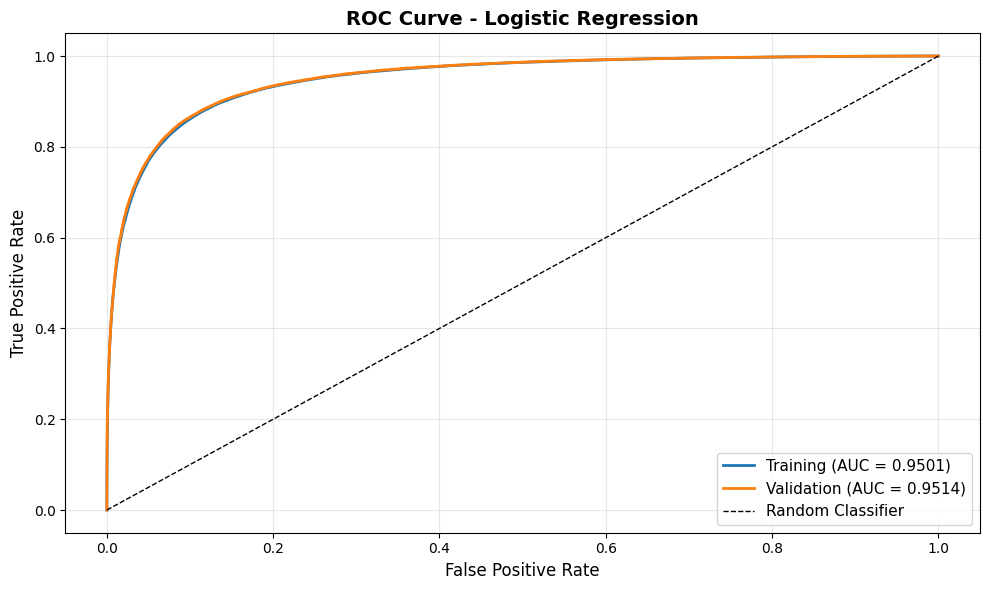

✓ ROC curves plotted successfully!


In [11]:
# Visualization of ROC Curves
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_pred_proba)
fpr_val, tpr_val, _ = roc_curve(y_val, y_val_pred_proba)

plt.figure(figsize=(10, 6))
plt.plot(fpr_train, tpr_train, label=f'Training (AUC = {train_auc:.4f})', linewidth=2)
plt.plot(fpr_val, tpr_val, label=f'Validation (AUC = {val_auc:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Logistic Regression', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("✓ ROC curves plotted successfully!")

In [12]:
# Make predictions on test data
print("=" * 70)
print("TEST DATA PREDICTIONS")
print("=" * 70)

y_test_pred = log_reg.predict(df_test_processed)
y_test_pred_proba = log_reg.predict_proba(df_test_processed)[:, 1]

print(f"\nTest set predictions completed!")
print(f"  Total test samples: {len(y_test_pred)}")
print(f"  Predicted Absence (Class 0): {(y_test_pred == 0).sum()}")
print(f"  Predicted Presence (Class 1): {(y_test_pred == 1).sum()}")

print(f"\nPrediction Probability Statistics:")
print(f"  Min probability: {y_test_pred_proba.min():.4f}")
print(f"  Max probability: {y_test_pred_proba.max():.4f}")
print(f"  Mean probability: {y_test_pred_proba.mean():.4f}")
print(f"  Std probability: {y_test_pred_proba.std():.4f}")

# Create submission dataframe
submission_df = df_test[['id']].copy()
submission_df['Heart Disease'] = y_test_pred
submission_df['Probability'] = y_test_pred_proba

print("\n" + "=" * 70)
print("SUBMISSION FILE PREVIEW")
print("=" * 70)
print(submission_df.head(10))

# Save submission
submission_df.to_csv('submission.csv', index=False)
print(f"\n✓ Submission file saved as 'submission.csv'")
print(f"  File size: {submission_df.shape[0]} rows, {submission_df.shape[1]} columns")

TEST DATA PREDICTIONS

Test set predictions completed!
  Total test samples: 270000
  Predicted Absence (Class 0): 152119
  Predicted Presence (Class 1): 117881

Prediction Probability Statistics:
  Min probability: 0.0002
  Max probability: 1.0000
  Mean probability: 0.4481
  Std probability: 0.4024

SUBMISSION FILE PREVIEW
       id  Heart Disease  Probability
0  630000              1     0.969532
1  630001              0     0.002861
2  630002              1     0.994658
3  630003              0     0.008693
4  630004              0     0.099717
5  630005              1     0.987821
6  630006              0     0.015001
7  630007              1     0.617925
8  630008              1     0.994084
9  630009              0     0.022905

✓ Submission file saved as 'submission.csv'
  File size: 270000 rows, 3 columns


In [13]:
# Save the trained model
import pickle

# Save the logistic regression model
with open('logistic_regression_model.pkl', 'wb') as f:
    pickle.dump(log_reg, f)

print("=" * 70)
print("MODEL SAVED")
print("=" * 70)
print("\n✓ Logistic Regression model saved as 'logistic_regression_model.pkl'")
print("\nYou can load this model anytime using:")
print("""
import pickle

with open('logistic_regression_model.pkl', 'rb') as f:
    model = pickle.load(f)

# Make predictions
predictions = model.predict(X_new)
""")

MODEL SAVED

✓ Logistic Regression model saved as 'logistic_regression_model.pkl'

You can load this model anytime using:

import pickle

with open('logistic_regression_model.pkl', 'rb') as f:
    model = pickle.load(f)

# Make predictions
predictions = model.predict(X_new)



In [10]:
# MODEL COMPARISON: Decision Tree, Random Forest, and XGBoost
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
import time

print("=" * 80)
print("MODEL COMPARISON: LOGISTIC REGRESSION vs DECISION TREE vs RANDOM FOREST vs XGBOOST")
print("=" * 80)

# Dictionary to store models and results
models = {}
results = {}

# 1. DECISION TREE
print("\n[1/3] Training Decision Tree...")
start_time = time.time()
dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_model.fit(X_train, y_train)
dt_time = time.time() - start_time

dt_train_pred = dt_model.predict(X_train)
dt_val_pred = dt_model.predict(X_val)
dt_train_proba = dt_model.predict_proba(X_train)[:, 1]
dt_val_proba = dt_model.predict_proba(X_val)[:, 1]

models['Decision Tree'] = dt_model
results['Decision Tree'] = {
    'train_accuracy': accuracy_score(y_train, dt_train_pred),
    'val_accuracy': accuracy_score(y_val, dt_val_pred),
    'train_precision': precision_score(y_train, dt_train_pred),
    'val_precision': precision_score(y_val, dt_val_pred),
    'train_recall': recall_score(y_train, dt_train_pred),
    'val_recall': recall_score(y_val, dt_val_pred),
    'train_f1': f1_score(y_train, dt_train_pred),
    'val_f1': f1_score(y_val, dt_val_pred),
    'train_auc': roc_auc_score(y_train, dt_train_proba),
    'val_auc': roc_auc_score(y_val, dt_val_proba),
    'training_time': dt_time
}
print(f"✓ Decision Tree trained in {dt_time:.2f} seconds")

# 2. RANDOM FOREST
print("\n[2/3] Training Random Forest...")
start_time = time.time()
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)
rf_time = time.time() - start_time

rf_train_pred = rf_model.predict(X_train)
rf_val_pred = rf_model.predict(X_val)
rf_train_proba = rf_model.predict_proba(X_train)[:, 1]
rf_val_proba = rf_model.predict_proba(X_val)[:, 1]

models['Random Forest'] = rf_model
results['Random Forest'] = {
    'train_accuracy': accuracy_score(y_train, rf_train_pred),
    'val_accuracy': accuracy_score(y_val, rf_val_pred),
    'train_precision': precision_score(y_train, rf_train_pred),
    'val_precision': precision_score(y_val, rf_val_pred),
    'train_recall': recall_score(y_train, rf_train_pred),
    'val_recall': recall_score(y_val, rf_val_pred),
    'train_f1': f1_score(y_train, rf_train_pred),
    'val_f1': f1_score(y_val, rf_val_pred),
    'train_auc': roc_auc_score(y_train, rf_train_proba),
    'val_auc': roc_auc_score(y_val, rf_val_proba),
    'training_time': rf_time
}
print(f"✓ Random Forest trained in {rf_time:.2f} seconds")

# 3. XGBoost
print("\n[3/3] Training XGBoost...")
start_time = time.time()
xgb_model = xgb.XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train, verbose=False)
xgb_time = time.time() - start_time

xgb_train_pred = xgb_model.predict(X_train)
xgb_val_pred = xgb_model.predict(X_val)
xgb_train_proba = xgb_model.predict_proba(X_train)[:, 1]
xgb_val_proba = xgb_model.predict_proba(X_val)[:, 1]

models['XGBoost'] = xgb_model
results['XGBoost'] = {
    'train_accuracy': accuracy_score(y_train, xgb_train_pred),
    'val_accuracy': accuracy_score(y_val, xgb_val_pred),
    'train_precision': precision_score(y_train, xgb_train_pred),
    'val_precision': precision_score(y_val, xgb_val_pred),
    'train_recall': recall_score(y_train, xgb_train_pred),
    'val_recall': recall_score(y_val, xgb_val_pred),
    'train_f1': f1_score(y_train, xgb_train_pred),
    'val_f1': f1_score(y_val, xgb_val_pred),
    'train_auc': roc_auc_score(y_train, xgb_train_proba),
    'val_auc': roc_auc_score(y_val, xgb_val_proba),
    'training_time': xgb_time
}
print(f"✓ XGBoost trained in {xgb_time:.2f} seconds")

# Add Logistic Regression results
results['Logistic Regression'] = {
    'train_accuracy': train_accuracy,
    'val_accuracy': val_accuracy,
    'train_precision': precision_score(y_train, y_train_pred),
    'val_precision': precision_score(y_val, y_val_pred),
    'train_recall': recall_score(y_train, y_train_pred),
    'val_recall': recall_score(y_val, y_val_pred),
    'train_f1': f1_score(y_train, y_train_pred),
    'val_f1': f1_score(y_val, y_val_pred),
    'train_auc': train_auc,
    'val_auc': val_auc,
    'training_time': 0  # Already trained
}

print("\n" + "=" * 80)
print("MODEL COMPARISON RESULTS")
print("=" * 80)

MODEL COMPARISON: LOGISTIC REGRESSION vs DECISION TREE vs RANDOM FOREST vs XGBOOST

[1/3] Training Decision Tree...
✓ Decision Tree trained in 1.03 seconds

[2/3] Training Random Forest...
✓ Random Forest trained in 17.71 seconds

[3/3] Training XGBoost...
✓ XGBoost trained in 0.52 seconds

MODEL COMPARISON RESULTS


In [11]:
# Create comparison dataframes
comparison_accuracy = pd.DataFrame({
    'Model': list(results.keys()),
    'Train Accuracy': [results[m]['train_accuracy'] for m in results.keys()],
    'Val Accuracy': [results[m]['val_accuracy'] for m in results.keys()],
    'Train AUC': [results[m]['train_auc'] for m in results.keys()],
    'Val AUC': [results[m]['val_auc'] for m in results.keys()],
})

comparison_f1 = pd.DataFrame({
    'Model': list(results.keys()),
    'Train F1': [results[m]['train_f1'] for m in results.keys()],
    'Val F1': [results[m]['val_f1'] for m in results.keys()],
    'Train Precision': [results[m]['train_precision'] for m in results.keys()],
    'Val Precision': [results[m]['val_precision'] for m in results.keys()],
    'Train Recall': [results[m]['train_recall'] for m in results.keys()],
    'Val Recall': [results[m]['val_recall'] for m in results.keys()],
})

print("\n" + "=" * 100)
print("ACCURACY AND AUC COMPARISON")
print("=" * 100)
print(comparison_accuracy.to_string(index=False))

print("\n" + "=" * 100)
print("PRECISION, RECALL, AND F1-SCORE COMPARISON")
print("=" * 100)
print(comparison_f1.to_string(index=False))

# Find best model by validation accuracy
best_model_name = comparison_accuracy.loc[comparison_accuracy['Val Accuracy'].idxmax(), 'Model']
best_val_acc = comparison_accuracy['Val Accuracy'].max()
best_val_auc = comparison_accuracy.loc[comparison_accuracy['Val Accuracy'].idxmax(), 'Val AUC']

print("\n" + "=" * 100)
print("🏆 BEST MODEL")
print("=" * 100)
print(f"Model: {best_model_name}")
print(f"Validation Accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
print(f"Validation AUC: {best_val_auc:.4f}")

# Overfitting detection
print("\n" + "=" * 100)
print("OVERFITTING ANALYSIS (Train - Val Accuracy Gap)")
print("=" * 100)
for idx, row in comparison_accuracy.iterrows():
    gap = row['Train Accuracy'] - row['Val Accuracy']
    status = "⚠️ OVERFITTING" if gap > 0.02 else "✓ Good"
    print(f"{row['Model']:20} | Gap: {gap:.4f} ({gap*100:.2f}%) | {status}")


ACCURACY AND AUC COMPARISON
              Model  Train Accuracy  Val Accuracy  Train AUC  Val AUC
      Decision Tree        0.885752      0.881833   0.952723 0.949445
      Random Forest        0.887238      0.886143   0.953958 0.952678
            XGBoost        0.888306      0.888730   0.955199 0.955269
Logistic Regression        0.882748      0.884913   0.950104 0.951401

PRECISION, RECALL, AND F1-SCORE COMPARISON
              Model  Train F1   Val F1  Train Precision  Val Precision  Train Recall  Val Recall
      Decision Tree  0.871506 0.867078         0.878966       0.874644      0.864172    0.859641
      Random Forest  0.872924 0.871737         0.882188       0.880665      0.863854    0.862987
            XGBoost  0.874332 0.874850         0.882146       0.882380      0.866655    0.867448
Logistic Regression  0.867501 0.869994         0.879177       0.881381      0.856131    0.858898

🏆 BEST MODEL
Model: XGBoost
Validation Accuracy: 0.8887 (88.87%)
Validation AUC: 0.9553

OV

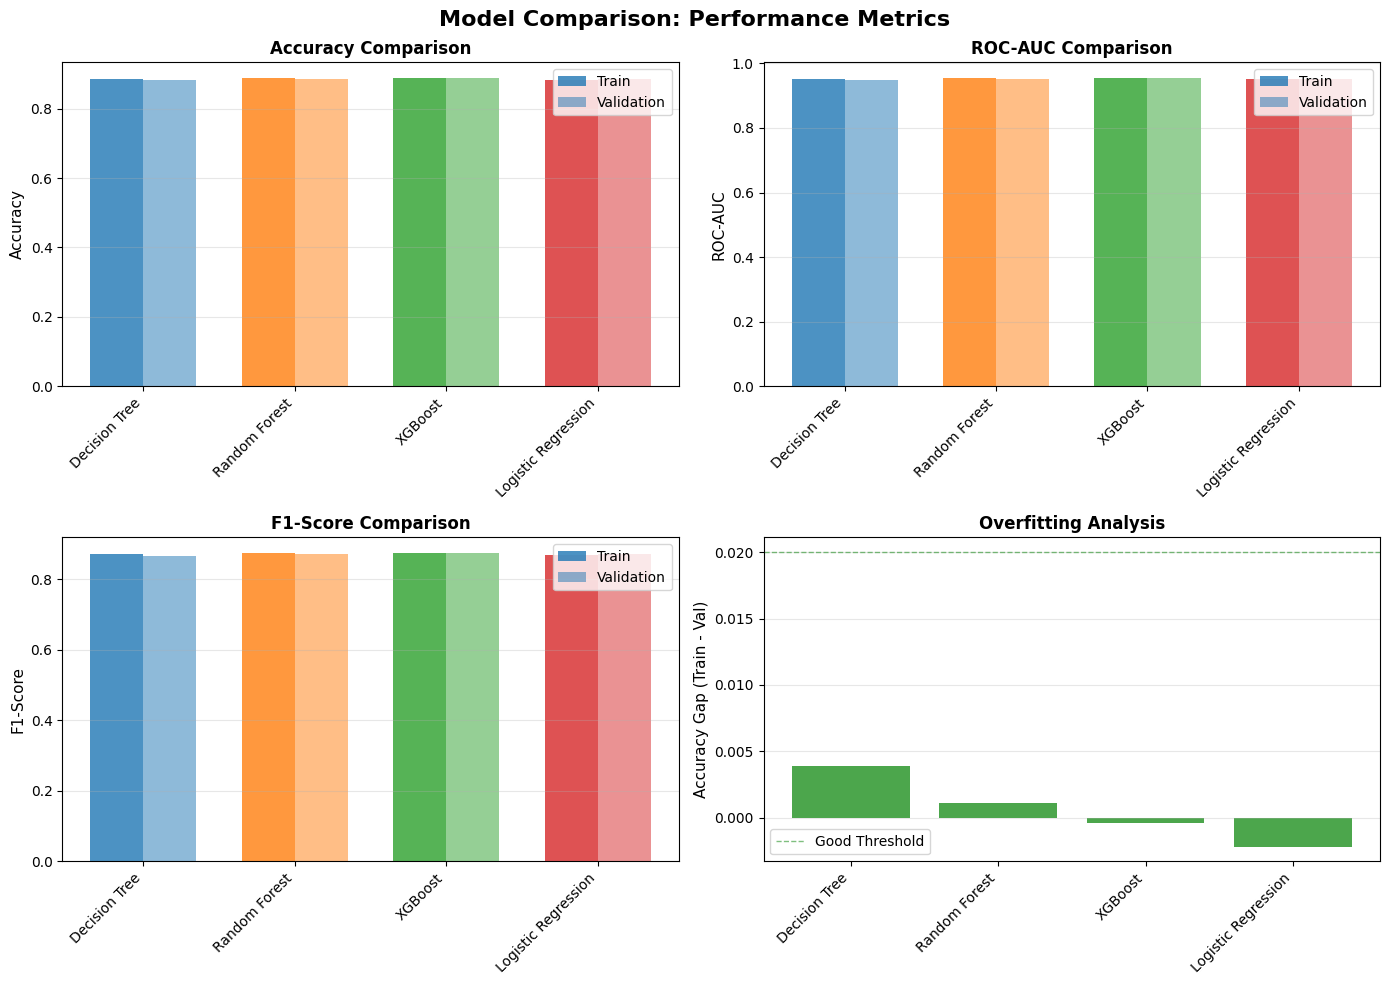


✓ Comparison visualizations completed!


In [12]:
# Visualization of model comparison
import matplotlib.pyplot as plt
import numpy as np

# Create comparison visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Comparison: Performance Metrics', fontsize=16, fontweight='bold')

models_list = list(results.keys())
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# 1. Accuracy Comparison
ax1 = axes[0, 0]
train_acc = [results[m]['train_accuracy'] for m in models_list]
val_acc = [results[m]['val_accuracy'] for m in models_list]
x_pos = np.arange(len(models_list))
width = 0.35
ax1.bar(x_pos - width/2, train_acc, width, label='Train', color=colors, alpha=0.8)
ax1.bar(x_pos + width/2, val_acc, width, label='Validation', color=colors, alpha=0.5)
ax1.set_ylabel('Accuracy', fontsize=11)
ax1.set_title('Accuracy Comparison', fontsize=12, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(models_list, rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# 2. AUC Comparison
ax2 = axes[0, 1]
train_auc = [results[m]['train_auc'] for m in models_list]
val_auc = [results[m]['val_auc'] for m in models_list]
ax2.bar(x_pos - width/2, train_auc, width, label='Train', color=colors, alpha=0.8)
ax2.bar(x_pos + width/2, val_auc, width, label='Validation', color=colors, alpha=0.5)
ax2.set_ylabel('ROC-AUC', fontsize=11)
ax2.set_title('ROC-AUC Comparison', fontsize=12, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(models_list, rotation=45, ha='right')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# 3. F1-Score Comparison
ax3 = axes[1, 0]
train_f1 = [results[m]['train_f1'] for m in models_list]
val_f1 = [results[m]['val_f1'] for m in models_list]
ax3.bar(x_pos - width/2, train_f1, width, label='Train', color=colors, alpha=0.8)
ax3.bar(x_pos + width/2, val_f1, width, label='Validation', color=colors, alpha=0.5)
ax3.set_ylabel('F1-Score', fontsize=11)
ax3.set_title('F1-Score Comparison', fontsize=12, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(models_list, rotation=45, ha='right')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# 4. Overfitting Gap (Train - Val Accuracy)
ax4 = axes[1, 1]
gaps = [train_acc[i] - val_acc[i] for i in range(len(models_list))]
colors_gap = ['green' if g <= 0.02 else 'orange' if g <= 0.05 else 'red' for g in gaps]
ax4.bar(x_pos, gaps, color=colors_gap, alpha=0.7)
ax4.set_ylabel('Accuracy Gap (Train - Val)', fontsize=11)
ax4.set_title('Overfitting Analysis', fontsize=12, fontweight='bold')
ax4.set_xticks(x_pos)
ax4.set_xticklabels(models_list, rotation=45, ha='right')
ax4.axhline(y=0.02, color='green', linestyle='--', linewidth=1, alpha=0.5, label='Good Threshold')
ax4.grid(axis='y', alpha=0.3)
ax4.legend()

plt.tight_layout()
plt.show()

print("\n✓ Comparison visualizations completed!")

In [13]:
# BEST MODEL SUMMARY
print("=" * 100)
print("🏆 MODEL RANKING (By Validation Accuracy)")
print("=" * 100)

ranking = sorted(results.items(), key=lambda x: x[1]['val_accuracy'], reverse=True)
for rank, (model_name, metrics) in enumerate(ranking, 1):
    print(f"\n{rank}. {model_name}")
    print(f"   Validation Accuracy: {metrics['val_accuracy']:.4f}")
    print(f"   Validation AUC:      {metrics['val_auc']:.4f}")
    print(f"   Validation F1:       {metrics['val_f1']:.4f}")
    print(f"   Training Time:       {metrics['training_time']:.2f} seconds")

best_model_name = ranking[0][0]
best_metrics = ranking[0][1]

print("\n" + "=" * 100)
print("✨ SELECTED BEST MODEL FOR PREDICTION")
print("=" * 100)
print(f"\nModel: {best_model_name}")
print(f"Validation Accuracy: {best_metrics['val_accuracy']:.4f} ({best_metrics['val_accuracy']*100:.2f}%)")
print(f"Validation AUC: {best_metrics['val_auc']:.4f}")
print(f"Validation F1-Score: {best_metrics['val_f1']:.4f}")
print(f"Training Time: {best_metrics['training_time']:.2f} seconds")

# Store the best model for predictions
best_model = models[best_model_name]
print(f"\n✓ Best model ({best_model_name}) is ready for final predictions!")

🏆 MODEL RANKING (By Validation Accuracy)

1. XGBoost
   Validation Accuracy: 0.8887
   Validation AUC:      0.9553
   Validation F1:       0.8749
   Training Time:       0.52 seconds

2. Random Forest
   Validation Accuracy: 0.8861
   Validation AUC:      0.9527
   Validation F1:       0.8717
   Training Time:       17.71 seconds

3. Logistic Regression
   Validation Accuracy: 0.8849
   Validation AUC:      0.9514
   Validation F1:       0.8700
   Training Time:       0.00 seconds

4. Decision Tree
   Validation Accuracy: 0.8818
   Validation AUC:      0.9494
   Validation F1:       0.8671
   Training Time:       1.03 seconds

✨ SELECTED BEST MODEL FOR PREDICTION

Model: XGBoost
Validation Accuracy: 0.8887 (88.87%)
Validation AUC: 0.9553
Validation F1-Score: 0.8749
Training Time: 0.52 seconds

✓ Best model (XGBoost) is ready for final predictions!
